# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
# !pip install tensorflow[and-cuda] numpy==1.25.2 -q

In [2]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.10.1


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [3]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2
import time


# Tensorflow modules
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16      
from tensorflow.keras.applications.vgg16 import preprocess_input


#Imports functions for evaluating the performance of machine learning models
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
# from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse           

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score)




# Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

In [5]:
# measuring how long it takes to run this notebook.
start_time = time.time()

# **Data Overview**


## Loading the data

In [6]:
images = np.load('images_proj.npy') # Load mages
labels = pd.read_csv('Labels_proj.csv') # Load labels

In [7]:
# Check the shape of images and labels
print(images.shape)
print(labels.shape)

(631, 200, 200, 3)
(631, 1)


# **Exploratory Data Analysis**

### Plot random images from each of the classes and print their corresponding labels.

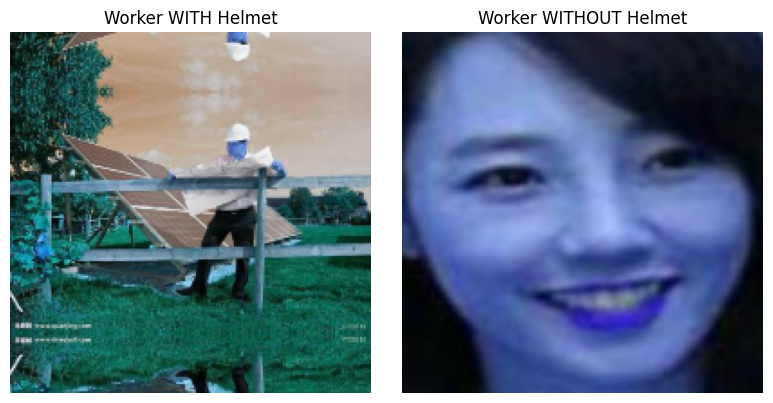

In [8]:
# separates data into classes
helmet_indices = np.where(labels == 1)[0]
no_helmet_indices = np.where(labels == 0)[0]  

# Select one image from each class
helmet_img = images[np.random.choice(helmet_indices)]
no_helmet_img = images[np.random.choice(no_helmet_indices)]

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Display "With Helmet" image
axes[0].imshow(helmet_img)
axes[0].set_title("Worker WITH Helmet")
axes[0].axis('off')

# Display "Without Helmet" image
axes[1].imshow(no_helmet_img)
axes[1].set_title("Worker WITHOUT Helmet")
axes[1].axis('off')

# Show the plots
plt.tight_layout()
plt.show()

## Checking for class imbalance


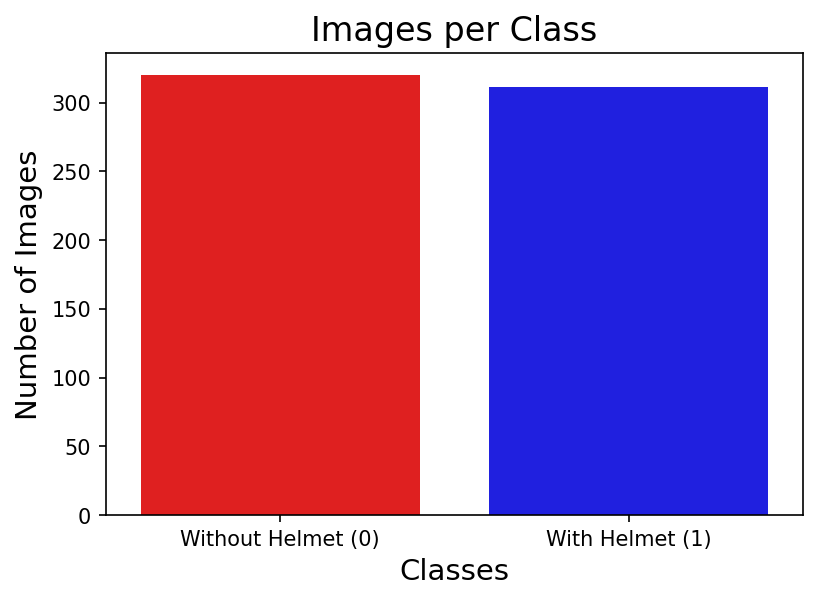

In [9]:
plt.figure(figsize=(6, 4), dpi=150)
sns.countplot(x=labels.iloc[:, 0], palette=['red', 'blue'])
plt.xlabel("Classes", fontsize=14)
plt.ylabel("Number of Images", fontsize=14)
plt.title("Images per Class", fontsize=16)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"]) ;

This is a a balanced dataset. While the number of images in each class is not exact, they are close. Each class has just over 300 images. 

# **Data Preprocessing**

## Converting images to grayscale

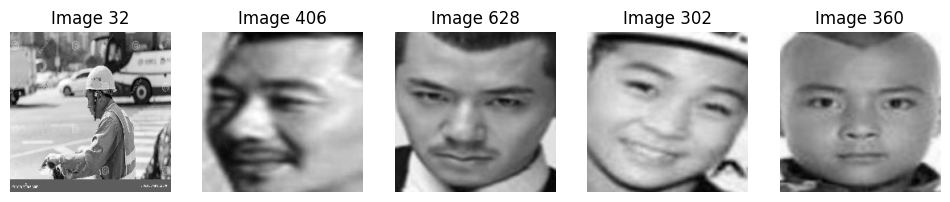

In [10]:
# Convert all images to grayscale
images_gray = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in images]

# Display a random sample of grayscale images
num_samples = 5  # number of images to show
sample_indices = random.sample(range(len(images_gray)), num_samples)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(images_gray[idx], cmap='gray')  # use gray colormap
    plt.axis("off")
    plt.title(f"Image {idx}")
plt.show()


In [11]:
# Checking to confirm that the images are now gray scale. Only height and width, no channels.
print(images[0].shape)        # original image
print(images_gray[0].shape)   # converted grayscale image

(200, 200, 3)
(200, 200)


## Split Dataset

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images_gray),labels , test_size=0.25, random_state=42,stratify=labels)

In [13]:
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [14]:
images.shape

(631, 200, 200, 3)

In [15]:
X_train.shape

(473, 200, 200)

In [16]:
X_val.shape

(79, 200, 200)

In [17]:
X_test.shape

(79, 200, 200)

CHecking the shape of the various data elements trying to decide on the appropriate split given the small size of the data set. This may be something that will need to be revisited depending on model performance. 

### Data Normalization

In [18]:
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

# **Model Building**

## Model Evaluation Criterion

## Utility Functions

In [19]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [20]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

## Model 1: Simple Convolutional Neural Network (CNN)

In [21]:
# Initializing Model
model_1 = Sequential()

# Feature extraction = Convolutional and pooling layers
model_1.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,1))) #Complete the code to define the shape of the input image
model_1.add(MaxPooling2D((4, 4), padding='same'))
model_1.add(Conv2D(16, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1.add(MaxPooling2D((4,4), padding='same')) #Complete the code to define the shape of the pooling kernel
model_1.add(Conv2D(8, (3,3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1.add(MaxPooling2D((4,4), padding='same')) #Complete the code to define the shape of the pooling kernel

# Flatten and Dense layers
model_1.add(Flatten())
model_1.add(Dense(8, activation='relu'))
model_1.add(Dense(4, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))  #Using the Sigmoid activation function sine this is binary classification 

# Compile the Model with Adam Optimizer
# opt = Adam(learning_rate=0.005) 
model_1.compile(optimizer='Adam', loss='binary_crossentropy', metrics=["accuracy"]) #Complete the code to define the metric of choice from Precision,f1_score,Recall

# Summary of the model parameters
model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 200, 200, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 50, 50, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 50, 50, 16)        4624      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 13, 13, 16)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 13, 13, 8)         1160      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 4, 4, 8)          0

In [22]:
# To determine input size
images_gray[0].shape

(200, 200)

In [23]:
history_1 = model_1.fit(
            X_train_normalized, y_train,
            epochs=15, 
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=20, 
            verbose=2
)

Epoch 1/15
24/24 - 13s - loss: 0.5858 - accuracy: 0.5011 - val_loss: 0.4352 - val_accuracy: 0.7975 - 13s/epoch - 562ms/step
Epoch 2/15
24/24 - 1s - loss: 0.3850 - accuracy: 0.8753 - val_loss: 0.3514 - val_accuracy: 0.9873 - 634ms/epoch - 26ms/step
Epoch 3/15
24/24 - 1s - loss: 0.3436 - accuracy: 0.9789 - val_loss: 0.3302 - val_accuracy: 1.0000 - 622ms/epoch - 26ms/step
Epoch 4/15
24/24 - 1s - loss: 0.3275 - accuracy: 0.9979 - val_loss: 0.3161 - val_accuracy: 1.0000 - 583ms/epoch - 24ms/step
Epoch 5/15
24/24 - 1s - loss: 0.3145 - accuracy: 0.9937 - val_loss: 0.3193 - val_accuracy: 1.0000 - 566ms/epoch - 24ms/step
Epoch 6/15
24/24 - 1s - loss: 0.3043 - accuracy: 0.9958 - val_loss: 0.2935 - val_accuracy: 1.0000 - 544ms/epoch - 23ms/step
Epoch 7/15
24/24 - 1s - loss: 0.2884 - accuracy: 0.9979 - val_loss: 0.2786 - val_accuracy: 1.0000 - 566ms/epoch - 24ms/step
Epoch 8/15
24/24 - 1s - loss: 0.2819 - accuracy: 0.9937 - val_loss: 0.2731 - val_accuracy: 1.0000 - 560ms/epoch - 23ms/step
Epoch 9/

### Vizualizing the predictions

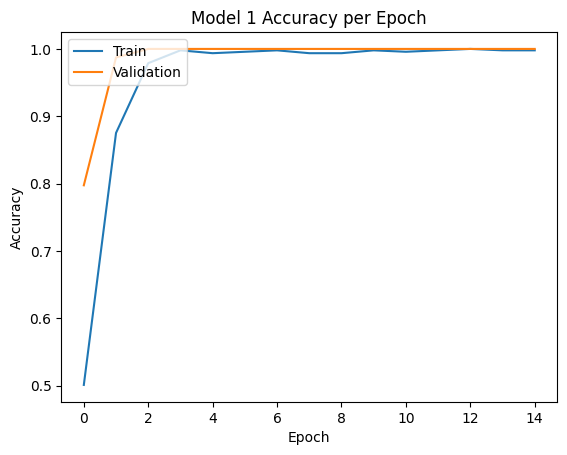

In [24]:
plt.plot(history_1.history['accuracy']) #Complete the code to plot the train metrics
plt.plot(history_1.history['val_accuracy']) #Complete the code to plot the validation data metrics
plt.title('Model 1 Accuracy per Epoch') #Complete the code to define the title for the plot
plt.ylabel('Accuracy') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

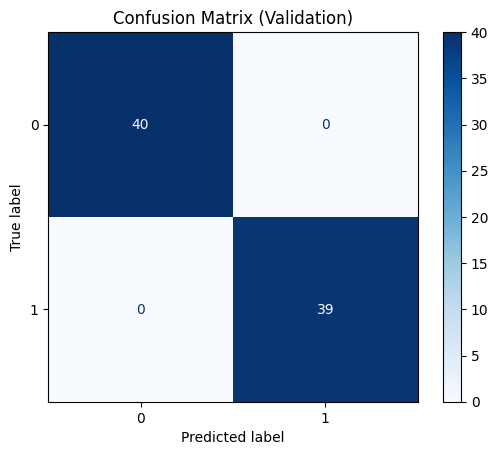

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        40
           1     1.0000    1.0000    1.0000        39

    accuracy                         1.0000        79
   macro avg     1.0000    1.0000    1.0000        79
weighted avg     1.0000    1.0000    1.0000        79

ROC AUC  : 1.0


In [25]:

y_prob = model_1.predict(X_val_normalized, verbose=0).ravel()   # shape (n,)
y_true = np.asarray(y_val).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Create Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()

# 5) Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# Optional: ROC AUC (works with probabilities)
try:
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
except ValueError:
    pass


## Model 2: (VGG-16 (Base))

In [26]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200, 200, 3))
vgg_model.summary()

58889256/58889256 [==============================] - 8s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 200, 200, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 200, 200, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 100, 100, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 100, 100, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 100, 100, 128)     147584    
                                                              

In [27]:
for layer in vgg_model.layers:
    layer.trainable = False

In [28]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

# Adding a dense output layer
model_2.add(Dense(8, activation='relu'))
model_2.add(Dense(4, activation='relu'))
model_2.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer.

In [29]:
model_2.compile(optimizer='Adam', loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"])
model_2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 6, 6, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 18432)             0         
                                                                 
 dense_3 (Dense)             (None, 8)                 147464    
                                                                 
 dense_4 (Dense)             (None, 4)                 36        
                                                                 
 dense_5 (Dense)             (None, 1)                 5         
                                                                 
Total params: 14,862,193
Trainable params: 147,505
Non-trainable params: 14,714,688
_________________________________________________________________


In [30]:
train_datagen = ImageDataGenerator(preprocessing_function=lambda x: preprocess_input(x * 255.0))

In [31]:
# Fitting the model
batch_size = 20

# Make 3-channel inputs (N, H, W, 3)
X_train_3ch = np.repeat(X_train_normalized[..., None].astype('float32'), 3, axis=-1)
X_val_3ch   = np.repeat(X_val_normalized[..., None].astype('float32'),   3, axis=-1)

history_2 = model_2.fit(
    train_datagen.flow(X_train_3ch, y_train, batch_size=batch_size, seed=42, shuffle=True),
    epochs=15,
    steps_per_epoch=math.ceil(X_train_3ch.shape[0] / batch_size),  # or omit; Keras can infer
    validation_data=(X_val_3ch, y_val),
    verbose=2
)


Epoch 1/15
24/24 - 13s - loss: 0.6478 - accuracy: 0.9049 - val_loss: 0.6935 - val_accuracy: 0.4937 - 13s/epoch - 553ms/step
Epoch 2/15
24/24 - 2s - loss: 0.3566 - accuracy: 0.9852 - val_loss: 0.6943 - val_accuracy: 0.4937 - 2s/epoch - 69ms/step
Epoch 3/15
24/24 - 2s - loss: 0.3332 - accuracy: 0.9873 - val_loss: 0.6954 - val_accuracy: 0.4937 - 2s/epoch - 69ms/step
Epoch 4/15
24/24 - 2s - loss: 0.3170 - accuracy: 0.9894 - val_loss: 0.6969 - val_accuracy: 0.4937 - 2s/epoch - 70ms/step
Epoch 5/15
24/24 - 2s - loss: 0.3026 - accuracy: 0.9979 - val_loss: 0.6987 - val_accuracy: 0.4937 - 2s/epoch - 69ms/step
Epoch 6/15
24/24 - 2s - loss: 0.2936 - accuracy: 1.0000 - val_loss: 0.7008 - val_accuracy: 0.4937 - 2s/epoch - 69ms/step
Epoch 7/15
24/24 - 2s - loss: 0.2852 - accuracy: 1.0000 - val_loss: 0.7035 - val_accuracy: 0.4937 - 2s/epoch - 69ms/step
Epoch 8/15
24/24 - 2s - loss: 0.2766 - accuracy: 1.0000 - val_loss: 0.7065 - val_accuracy: 0.4937 - 2s/epoch - 71ms/step
Epoch 9/15
24/24 - 2s - loss:

### Visualizing the prediction:

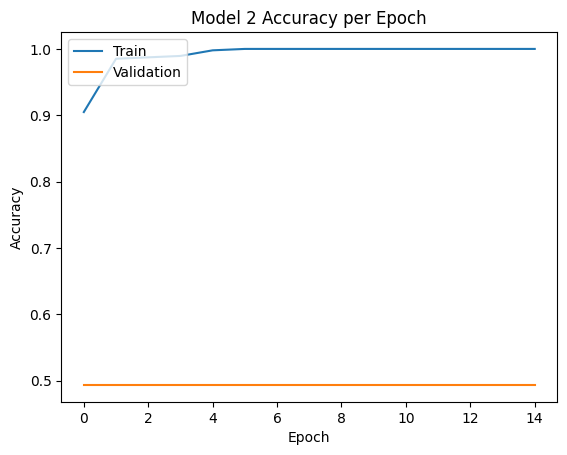

In [32]:
plt.plot(history_2.history['accuracy']) #Complete the code to plot the train metrics
plt.plot(history_2.history['val_accuracy']) #Complete the code to plot the validation data metrics
plt.title('Model 2 Accuracy per Epoch') #Complete the code to define the title for the plot
plt.ylabel('Accuracy') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

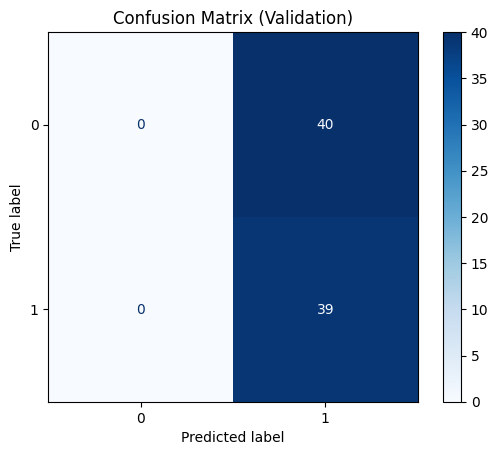

Accuracy : 0.4936708860759494
Precision: 0.4936708860759494
Recall   : 1.0
F1-score : 0.6610169491525424

Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        40
           1     0.4937    1.0000    0.6610        39

    accuracy                         0.4937        79
   macro avg     0.2468    0.5000    0.3305        79
weighted avg     0.2437    0.4937    0.3263        79

ROC AUC  : 0.5


In [33]:

y_prob = model_2.predict(X_val_3ch, verbose=0).ravel()   # shape (n,)
y_true = np.asarray(y_val).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Create Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()

# 5) Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# Optional: ROC AUC (works with probabilities)
try:
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
except ValueError:
    pass


## Model 3: (VGG-16 (Base + FFNN))

#### Visualizing the predictions

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

#### Visualizing the predictions

# **Model Performance Comparison and Final Model Selection**

## Test Performance

# **Actionable Insights & Recommendations**

-
-

<font size=5 color='blue'>Power Ahead!</font>
___

In [34]:
end_time = time.time()
total_time = (end_time - start_time)/60
print(round(total_time,3))

1.325
